# TMD A12B for specific eta

In [1]:
pip install -U pysr

Note: you may need to restart the kernel to use updated packages.


Julia and Julia dependencies are installed at first import:

In [2]:
import pysr

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Now, let's import everything else as well as the PySRRegressor:


In [4]:
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split
import h5py

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# PySR for A12B eta = 8:


In [9]:

file_path = "/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/allPL_eta_bP_bsq_mean_err_forReImAmps.h5"
data_list = []

P1 = 1
with h5py.File(file_path, "r") as h5_file:
    for eta in range(1, 11):
        dataset_name = f"Pl-{P1}/eta_{eta}_bP_bsq_ReA12B_err"
        data_list.append(np.array(h5_file[dataset_name]))
        
data_for_eta = np.vstack(data_list)


unique_vals = np.unique(data_for_eta[:, 2])
print("All values of b^2:", np.unique(data_for_eta[:, 2]))

data_for_eta = data_for_eta[data_for_eta[:, 2] == 25]

# Extract bLbT and A12B
bLbT = data_for_eta[:, 0:2]  
A2B = data_for_eta[:, 3]   
A2Berr = data_for_eta[:, 4]
A2Bweight = [1/sigma**2 for sigma in A2Berr]


#print("bLbT =", bLbT)
#print("A12B =", A12B)
#print("A12Berr =", A12Berr)

All values of b^2: [ 1.  2.  4.  5.  8.  9. 16. 17. 18. 20. 25. 32. 36. 45. 49. 50. 68.]


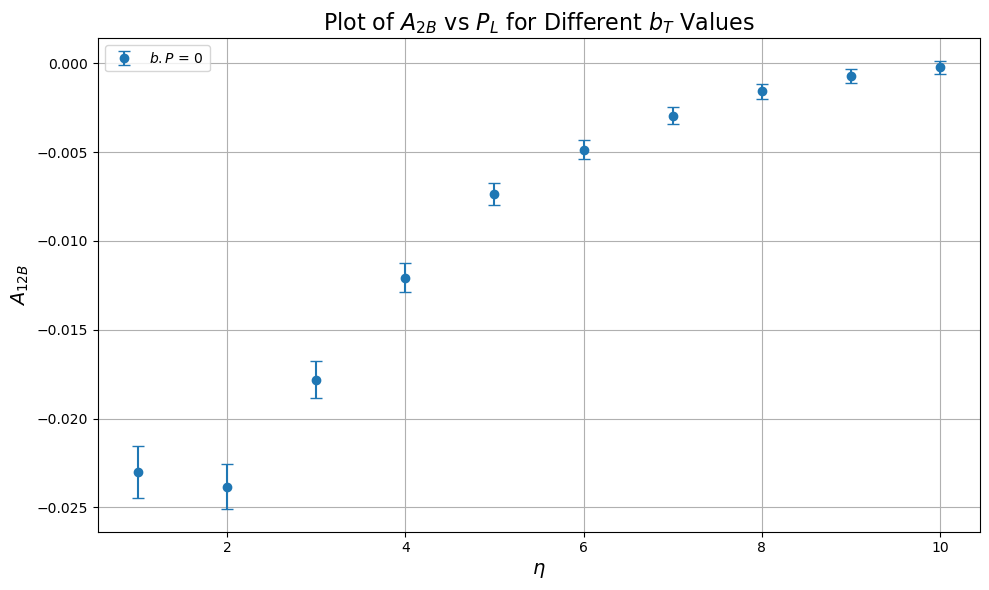

In [11]:

# Extract unique bT values
unique_bT = np.unique(bLbT[:, 1])

# Create the plot
plt.figure(figsize=(10, 6))

for i, bT in enumerate(unique_bT):
    #if bT<1 :
    #    continue
    # Filter data for the current bT value
    mask = bLbT[:, 1] == bT
    bL_values = bLbT[mask, 0]
    A2B_values = A2B[mask]
    A2B_errors = A2Berr[mask]

    # Plot with error bars
    plt.errorbar(
        bL_values,
        A2B_values,
        yerr=A2B_errors,
        fmt='o',
        label=f"$b.P$ = {int(bT)}",
        capsize=4
    )
# Add labels, legend, and grid
plt.xlabel("$\\eta$", fontsize=14)
plt.ylabel("$A_{12B}$", fontsize=14)
plt.title("Plot of $A_{2B}$ vs $P_L$ for Different $b_T$ Values", fontsize=16)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


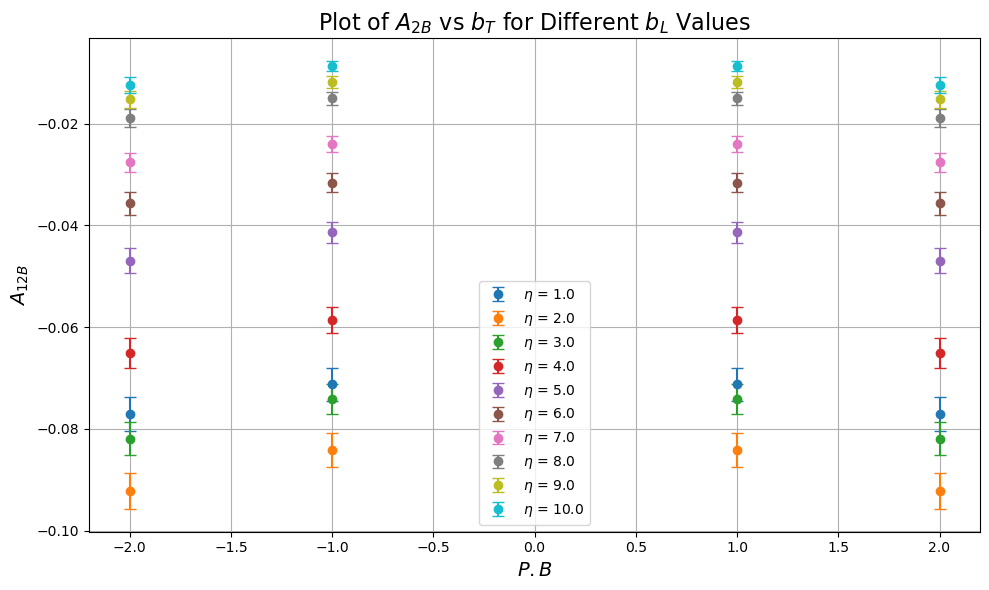

In [10]:
# Extract unique bT values
unique_bL = np.unique(bLbT[:, 0])

# Create the plot
plt.figure(figsize=(10, 6))

for i, bL in enumerate(unique_bL):
    #if bT<1 :
    #    continue
    # Filter data for the current bT value
    mask = bLbT[:, 0] == bL
    bT_values = bLbT[mask, 1]
    A2B_values = A2B[mask]
    A2B_errors = A2Berr[mask]

    # Plot with error bars
    plt.errorbar(
        bT_values,
        A2B_values,
        yerr=A2B_errors,
        fmt='o',
        label=f"$\\eta$ = {bL}",
        capsize=4
    )
# Add labels, legend, and grid
plt.xlabel("$P.B$", fontsize=14)
plt.ylabel("$A_{12B}$", fontsize=14)
plt.title("Plot of $A_{2B}$ vs $b_T$ for Different $b_L$ Values", fontsize=16)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


By default, we will set up 30 populations of expressions (which evolve independently except for migrations), use 4 threads, and use `"best"` for our model selection strategy:

In [11]:
default_pysr_params = dict(
    populations=30,
    model_selection="best",
)

In [12]:
from sympy import exp, sech, symbols, Function

custom_loss_function = """
using Symbolics

function eval_loss(tree, dataset::Dataset{T,L}, options)::L where {T,L}
    prediction, flag = eval_tree_array(tree, dataset.X, options)
    if !flag
        return L(Inf)
    end
    
    wmse = sum((prediction .- dataset.y).^2 .* dataset.weights) / (dataset.n - 3)
    return wmse
end
"""

extra_sympy_mappings = {
    "gaussian": lambda x: exp(-x**2)
}



model = PySRRegressor(
    niterations=100,
    maxsize = 50,
    unary_operators=["gaussian(x) = exp(-x^2)"],
    binary_operators=["*", "+", "/", "^"],
    extra_sympy_mappings=extra_sympy_mappings,  # Include the custom mappings
    loss_function=custom_loss_function,  # Use the custom loss function
    nested_constraints = {"gaussian": {"gaussian": 0}, "^": {"^": 0}},
    constraints={'^': (-1, 1)}

)

modelold = PySRRegressor(
    niterations=100,
    maxsize = 50,
    unary_operators=["exp"],
    binary_operators=["*", "+", "-", "/", "^"],
    #extra_sympy_mappings=extra_sympy_mappings,  # Include the custom mappings
    loss_function=custom_loss_function,  # Use the custom loss function
    nested_constraints = { "exp": {"exp": 0}, "^": {"^": 0, "+": 0},  "/": {"^": 0, "+": 0}},
    constraints={'^': (-1, 1)}

)


model.fit(bLbT, A2B, weights=A2Bweight, variable_names=['n', 'bP'])



/opt/homebrew/anaconda3/lib/python3.11/site-packages/pysr/sr.py:1469: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 9.210e+04
Progress: 416 / 3100 total iterations (13.419%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.360e+01  0.000e+00  y = -0.0013752
4           5.350e+01  6.378e-04  y = gaussian(bP) + -0.0014735
5           1.942e+01  1.013e+00  y = (0.73506 ^ n) * -0.012324
6           8.166e+00  8.662e-01  y = (gaussian(n) ^ 0.051353) * -0.010949
7           9.421e-01  2.160e+00  y = (n * -0.02784) * (0.45822 ^ n)
9           5.349e-01  2.830e-01  y = ((n + 0.085775) * (0.46388 ^ n)) * -0.025823
11          5.349e-01  2.751e-05  y = (0.464 ^ n) * (((n * 0.24965) + 0.021389) * -0.10333)
16          1.789e-01  2.191e-01  y = ((0.6627 ^ n) * -0.023701) * (gaussian((n * -0.17168) ...
                                      + -0.45185) * (n + 0.12967))
39  

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.360e+01  0.000e+00  y = -0.0013752
4           5.350e+01  6.378e-04  y = gaussian(bP) + -0.0014735
5           1.714e+01  1.138e+00  y = (n * 0.00091688) + -0.0082404
6           8.164e+00  7.416e-01  y = gaussian(n / 4.4355) * -0.010887
7           9.421e-01  2.159e+00  y = (0.4583 ^ n) * (n * -0.027828)
9           5.349e-01  2.830e-01  y = ((0.46416 ^ n) * (n + 0.086021)) * -0.025778
11          1.912e-01  5.144e-01  y = ((0.37175 ^ n) * -0.018922) * ((n + 0.33274) ^ 1.8005)
13          1.909e-01  8.550e-04  y = -0.086412 * ((0.37465 ^ n) * (((n * 0.42859) + 0.13719...
                                      ) ^ 1.7685))
14          1.753e-01  8.498e-02  y = ((((0.57598 ^ n) * n) + 0.14715) * -0.01727) * gaussia...
                                      n(n * 0.20595)
16          1.753e-01  1.730e-04  y = ((((n + 0.017188) * (0.576

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                      -0.0013752155   
	1         0.000639                       gaussian(bP) + -0.0014735005   
	2         1.138302                  (n * 0.0009168793) + -0.008240402   
	3         0.741646             gaussian(n / 4.4354725) * -0.010886517   
	4         2.159394               (0.4582952 ^ n) * (n * -0.027827911)   
	5         0.283039  ((0.46415523 ^ n) * (n + 0.08602084)) * -0.025...   
	6         0.514366  ((0.37175205 ^ n) * -0.018922148) * ((n + 0.33...   
	7         0.000855  -0.08641179 * ((0.37465364 ^ n) * (((n * 0.428...   
	8         0.084980  ((((0.5759816 ^ n) * n) + 0.14714946) * -0.017...   
	9         0.000173  ((((n + 0.017187502) * (0.5760175 ^ n)) + 0.12...   
	10        0.014821  (((0.41204563 ^ n) + gaussian(bP)) * ((n + -0....   
	11        0.005372  (gaussian(bP) + (0.40999648 ^ n)) * (-0.046212...   
	12        0.056955  (gaussian(-2.0896943 / (n + -1.4359688)) + n) ...   
	13        0.091141  ((0.41502014 ^ n) * (gaussian(-1.7792059 / (n ...   
	14        0.340958  (n + (gaussian(1.7206655 / (n + -1.6160159)) +...   
	15        0.018584  ((gaussian(bP * ((-0.35394898 ^ n) * ((bP ^ n)...   
	16        0.173589  -0.038163695 * (((n + (gaussian(1.7514312 / (-...   
	17        0.057072  (gaussian((((-0.45989323 ^ n) / -964.07025) * ...   
	18        0.163199  (gaussian(((-0.66733485 ^ n) / (bP * -0.631458...   
	19        0.027260  gaussian((((0.6091004 ^ n) * 0.839619) / (bP *...   
	20        0.032356  ((n + gaussian(1.8305318 / (n + -1.593217))) +...   
	21        0.060985  ((n + (gaussian(1.8175052 / (n + -1.5471131)) ...   
	22        0.181724  (gaussian(1.8392427 / (n + -1.5810665)) + (n +...   
	23  >>>>  0.108138  ((gaussian(1.7249328 / (n + -1.5720892)) + -0....   
	
	         loss  complexity  
	0   53.601340           1  
	1   53.498672           4  
	2   17.138964           5  
	3    8.163790           6  
	4    0.942061           7  
	5    0.534853           9  
	6    0.191188          11  
	7    0.190862          13  
	8    0.175312          14  
	9    0.175252          16  
	10   0.167630          19  
	11   0.165839          21  
	12   0.156657          22  
	13   0.143011          23  
	14   0.072313          25  
	15   0.067132          29  
	16   0.047441          31  
	17   0.042324          33  
	18   0.030537          35  
	19   0.028917          37  
	20   0.026242          40  
	21   0.024689          41  
	22   0.020587          42  
	23   0.013358          46  
]

  - outputs/20250924_131302_p2Z2Ny/hall_of_fame.csv


In [26]:
pick = 10
model.sympy(pick)

(0.41204563**n + exp(-bP**2))*(n - 0.29969338 + exp(-1.01772574057561/(0.615337471067601*n - 1)**2))*(-0.041200664)

In [88]:
#model.latex(pick)

model.predict([[-1,-4]], pick)

array([0.19042047])

We can also view the SymPy of any other expression in the list, using the index of it in `model.equations_`.

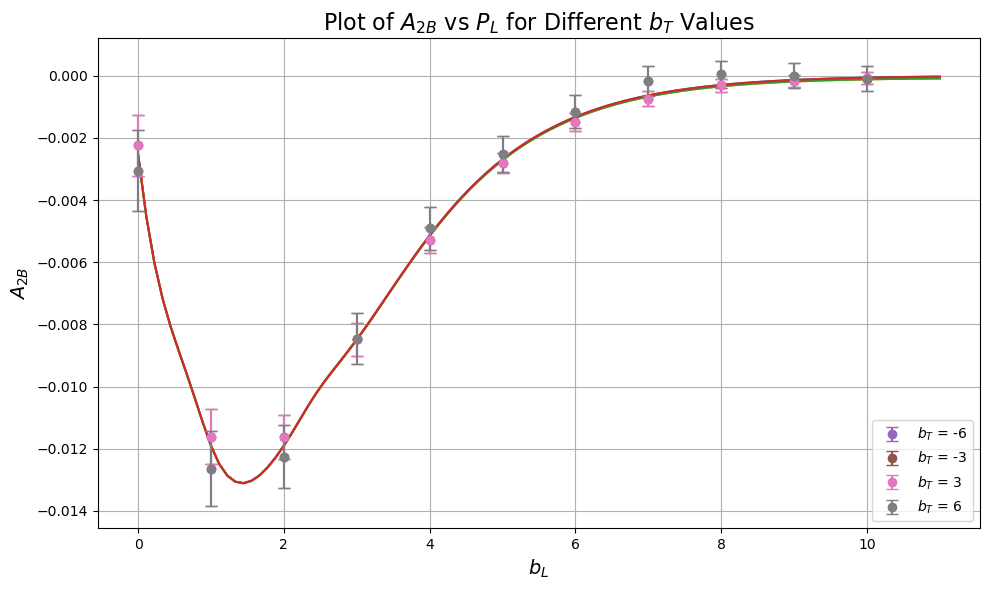

(0.41204563**n + exp(-bP**2))*(n - 0.29969338 + exp(-1.01772574057561/(0.615337471067601*n - 1)**2))*(-0.041200664)

In [30]:

bL_plot = np.linspace(0,11, 100)
plt.figure(figsize=(10, 6))

for bT in unique_bT:
    bLbT_plot = np.array([[bL, bT] for bL in bL_plot])
    predictions = model.predict(bLbT_plot, pick)
    plt.plot(bLbT_plot[:,0] , predictions)
for i, bT in enumerate(unique_bT):
    #if bT<1 :
    #    continue
    # Filter data for the current bT value
    mask = bLbT[:, 1] == bT
    bL_values = bLbT[mask, 0]
    A2B_values = A2B[mask]
    A2B_errors = A2Berr[mask]

    # Plot with error bars
    plt.errorbar(bL_values, A2B_values, yerr=A2B_errors, fmt='o', label=f"$b_T$ = {int(bT)}", capsize=4)
# Add labels, legend, and grid
plt.xlabel("$b_{L}$", fontsize=14)
plt.ylabel("$A_{2B}$", fontsize=14)
plt.title("Plot of $A_{2B}$ vs $P_L$ for Different $b_T$ Values", fontsize=16)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


model.sympy(pick)

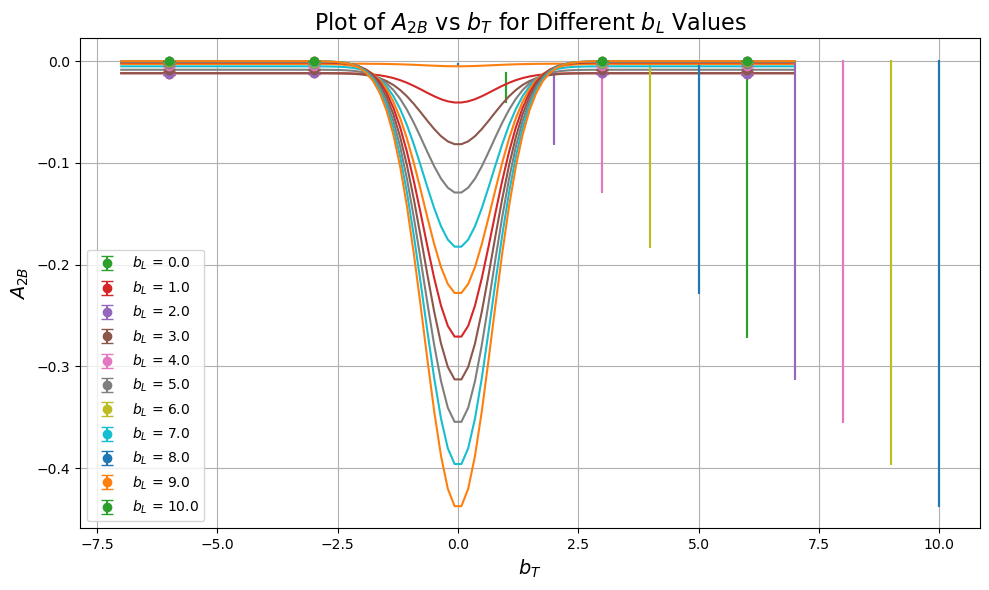

(0.41204563**n + exp(-bP**2))*(n - 0.29969338 + exp(-1.01772574057561/(0.615337471067601*n - 1)**2))*(-0.041200664)

In [32]:

bT_plot = np.linspace(-7,7, 100)
plt.figure(figsize=(10, 6))

for bL in unique_bL:
    bLbT_plott = np.array([[bL, bT] for bT in bT_plot])
    predictions = model.predict(bLbT_plott, pick)
    plt.plot(bLbT_plott, predictions)

for i, bL in enumerate(unique_bL):
    #if bT<1 :
    #    continue
    # Filter data for the current bT value
    mask = bLbT[:, 0] == bL
    bT_values = bLbT[mask, 1]
    A2B_values = A2B[mask]
    A2B_errors = A2Berr[mask]

    # Plot with error bars
    plt.errorbar(
        bT_values,
        A2B_values,
        yerr=A2B_errors,
        fmt='o',
        label=f"$b_L$ = {bL}",
        capsize=4
    )
# Add labels, legend, and grid
plt.xlabel("$b_T$", fontsize=14)
plt.ylabel("$A_{2B}$", fontsize=14)
plt.title("Plot of $A_{2B}$ vs $b_T$ for Different $b_L$ Values", fontsize=16)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

model.sympy(pick)


In [79]:
model.equations_[["complexity", "loss", "equation"]]

,complexity,loss,equation
0,1,3496.224600,0.011494168
1,5,2694.088600,(0.04454696 ^ bT) ^ bT
2,6,2561.390900,sin((0.044563945 ^ bT) ^ bT)
3,7,2124.244400,0.051070243 / ((bT * bT) + 0.08197257)
4,9,2102.989500,0.048363578 / (((bT * bT) ^ 0.8272242) + 0.077...
5,10,847.203860,0.52314216 / ((bL * bL) + exp(bT * bT))
6,11,249.527570,0.28998753 / ((bL * bL) + ((bT * bT) + 0.41461...
7,12,7.171931,sin((((bL * bL) + (bT * bT)) + 1.2760693) ^ -1...
8,13,7.049274,(1.0949587 / ((bT * bT) + ((bL * bL) + 1.45352...
9,14,1.363645,sin(((bL * (bL * 0.87349325)) + ((bT * bT) + 1...
